In [ ]:
from google.colab import files

files.upload()

In [7]:
!unzip -q drum_dataset.zip -d drum_dataset

In [8]:
import pandas as pd

labels_df = pd.read_csv('/content/drum_dataset/dataset/labels.csv')

print('First 5 rows of labels_df:')
print(labels_df.head())

First 5 rows of labels_df:
                    filename          label
0  hiphop_gospel.wav_000.png  hiphop_gospel
1  hiphop_gospel.wav_001.png  hiphop_gospel
2  hiphop_gospel.wav_002.png  hiphop_gospel
3  hiphop_gospel.wav_003.png  hiphop_gospel
4  hiphop_gospel.wav_004.png  hiphop_gospel

DataFrame information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  400 non-null    object
 1   label     400 non-null    object
dtypes: object(2)
memory usage: 6.4+ KB


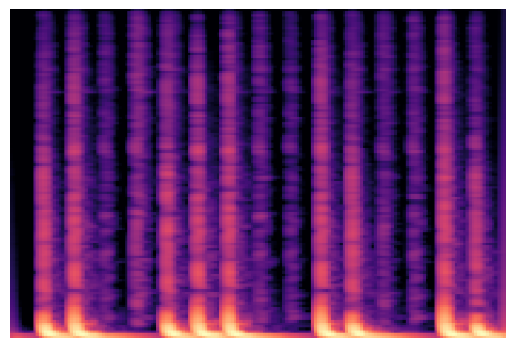

In [18]:
import os
from skimage.io import imread
import matplotlib.pyplot as plt

images_dir = '/content/drum_dataset/dataset/images'
one_img = os.listdir(images_dir)[2]
img_path = os.path.join(images_dir, one_img)
img = imread(img_path)

plt.imshow(img)
plt.axis('off')
plt.show()

In [51]:
img.shape

(308, 465, 4)

In [19]:
labels_df = pd.read_csv('/content/drum_dataset/dataset/labels.csv')

# Keep only images that exist
labels_df['filepath'] = labels_df['filename'].apply(lambda x: os.path.join(images_dir, x))
labels_df = labels_df[labels_df['filepath'].apply(os.path.exists)]

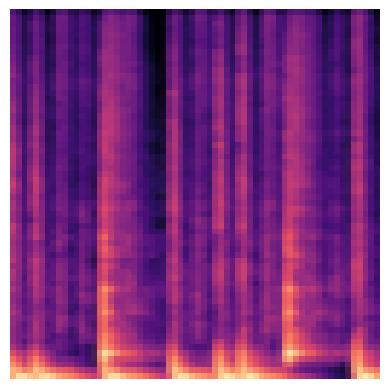

In [52]:
from skimage.transform import resize
import numpy as np
i = 0
IMG_SIZE = (64, 64)  # small = fast

X = []
y = []

for _, row in labels_df.iterrows():
    img = imread(row['filepath'])

    # resize
    img_resized = resize(img, IMG_SIZE, anti_aliasing=True)
    if 1 > i:
        plt.imshow(img_resized)
        plt.axis('off')
        plt.show()
        i += 1

    # flatten image to vector
    X.append(img_resized.flatten())
    y.append(row['label'])

X = np.array(X)
y = np.array(y)

In [22]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

In [70]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [71]:
from sklearn.ensemble import RandomForestClassifier

model2 = RandomForestClassifier(n_estimators=100)
model2.fit(X_train, y_train)

RandomForestClassifier()

In [72]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

y_pred = model2.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 1.0
Accuracy: 1.0


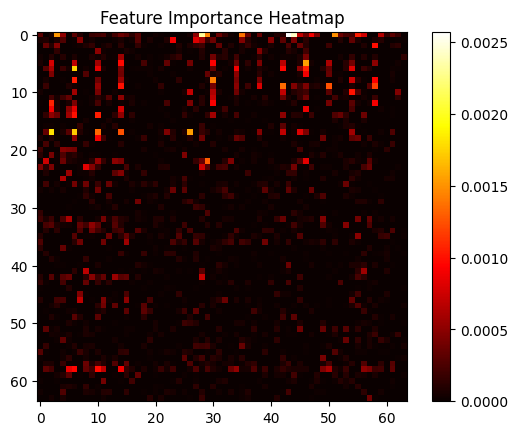

In [46]:
importances = model2.feature_importances_

# reshape back to image
importance_img = importances.reshape(64, 64, -1)

# if RGB → average channels
importance_img = importance_img.mean(axis=2)

plt.imshow(importance_img, cmap='hot')
plt.title("Feature Importance Heatmap")
plt.colorbar()
plt.show()